# Kidney Tumor Identification System
### End-to-End MLOps Pipeline -

**Architecture:** VGG16 Transfer Learning - Binary Classification (Tumor / Normal)  
**MLOps Stack:** MLflow (DagsHub) | MongoDB | Groq LLM | Flask Prediction App  
**Stages:** Data Ingestion -> Base Model -> Training -> Evaluation -> Prediction App -> Output ZIP  

> All outputs from every stage are saved and bundled into a final ZIP at the end.  
> Secrets are loaded from Colab Secret Store - never hard-coded.  
> Azure deployment excluded; includes Groq LLM for AI report generation.

## Section 1 - Environment Setup & Secret Configuration

In [1]:
# 1.1  Mount Google Drive (optional - survives session restarts)
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    USE_GDRIVE = True
    print('Google Drive mounted.')
except Exception:
    USE_GDRIVE = False
    print('Drive mount skipped (non-Colab environment).')


Drive mount skipped (non-Colab environment).


In [2]:
# 1.2  Load ALL secrets from Colab Secret Store
#      Add these keys under: Runtime -> Manage secrets
#        MONGO_DB_URL, MLFLOW_TRACKING_URI, MLFLOW_TRACKING_USERNAME,
#        MLFLOW_TRACKING_PASSWORD, GROQ_API_KEY
import os
from google.colab import userdata

# MongoDB
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# MLflow / DagsHub
USE_DAGSHUB = True  # set False to log locally

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow - logs saved inside Colab session
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

# Groq LLM
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

print('Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")
print(f"   MONGO_DB_URL        = {'*' * 12} (loaded)")
print(f"   GROQ_API_KEY        = {'*' * 12} (loaded)")


Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow
   MONGO_DB_URL        = ************ (loaded)
   GROQ_API_KEY        = ************ (loaded)


## Section 2 - Install Dependencies

In [3]:
%%capture install_log
# All required packages
# Note: langchain >=0.2 syntax is used throughout (ChatGroq, langchain_core)
!pip install -q \
    tensorflow \
    mlflow \
    gdown \
    python-box\
    ensure \
    PyYAML \
    joblib \
    scipy \
    seaborn \
    matplotlib \
    tqdm \
    scikit-learn \
    Flask \
    flask-cors \
    pymongo \
    dnspython \
    groq \
    'langchain>=0.2.0' \
    'langchain-groq>=0.1.0' \
    'langchain-core>=0.2.0' \
    pyngrok
print('All packages installed.')


In [4]:
# 2.2  Verify key imports
import tensorflow as tf
import mlflow
import groq as groq_sdk
print(f'TensorFlow  : {tf.__version__}')
print(f'MLflow      : {mlflow.__version__}')
print(f'Groq SDK    : {groq_sdk.__version__}')


TensorFlow  : 2.19.0
MLflow      : 3.11.1
Groq SDK    : 0.37.1


## Section 3 - Project Directory Scaffold

In [5]:
# 3.1  Create canonical project structure mirroring the original repo layout
import os
from pathlib import Path

PROJECT_ROOT = Path('/content/KidneyTumorSystem')
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)
print(f'Working directory: {os.getcwd()}')

dirs = [
    'config',
    'artifacts/data_ingestion',
    'artifacts/prepare_base_model',
    'artifacts/prepare_callbacks/checkpoint_dir',
    'artifacts/prepare_callbacks/tensorboard_log_dir',
    'artifacts/training',
    'artifacts/evaluation',
    'logs',
    'src/cnnClassifier/components',
    'src/cnnClassifier/config',
    'src/cnnClassifier/constants',
    'src/cnnClassifier/entity',
    'src/cnnClassifier/pipeline',
    'src/cnnClassifier/utils',
    'outputs',
    'templates',
]
for d in dirs:
    Path(d).mkdir(parents=True, exist_ok=True)
print('Directory scaffold created.')


Working directory: /content/KidneyTumorSystem
Directory scaffold created.


## Section 4 - Write Source-Code Modules to Disk

In [6]:
# 4.1  Write config/config.yaml and params.yaml
from pathlib import Path

config_yaml = '''artifacts_root: artifacts

data_ingestion:
  root_dir: artifacts/data_ingestion
  source_URL: https://drive.google.com/file/d/1vlhZ5c7abUKF8xXERIw6m9Te8fW7ohw3/view?usp=sharing
  local_data_file: artifacts/data_ingestion/data.zip
  unzip_dir: artifacts/data_ingestion

prepare_base_model:
  root_dir: artifacts/prepare_base_model
  base_model_path: artifacts/prepare_base_model/base_model.h5
  updated_base_model_path: artifacts/prepare_base_model/base_model_updated.h5

prepare_callbacks:
  root_dir: artifacts/prepare_callbacks
  tensorboard_root_log_dir: artifacts/prepare_callbacks/tensorboard_log_dir
  checkpoint_model_filepath: artifacts/prepare_callbacks/checkpoint_dir/model.h5

training:
  root_dir: artifacts/training
  trained_model_path: artifacts/training/model.h5
'''

params_yaml = '''AUGMENTATION: True
IMAGE_SIZE: [224, 224, 3]
BATCH_SIZE: 16
INCLUDE_TOP: False
EPOCHS: 5
CLASSES: 2
WEIGHTS: imagenet
LEARNING_RATE: 0.01
'''

Path('config/config.yaml').write_text(config_yaml)
Path('params.yaml').write_text(params_yaml)
print('config.yaml and params.yaml written.')


config.yaml and params.yaml written.


In [7]:
# 4.2  src/cnnClassifier/__init__.py - Logger setup
from pathlib import Path

init_src = '''import os, sys, logging

_LOG_FMT  = "[%(asctime)s: %(levelname)s: %(module)s: %(message)s]"
_LOG_DIR  = "logs"
_LOG_FILE = os.path.join(_LOG_DIR, "running_logs.log")
os.makedirs(_LOG_DIR, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format=_LOG_FMT,
    handlers=[
        logging.FileHandler(_LOG_FILE),
        logging.StreamHandler(sys.stdout),
    ],
)

logger = logging.getLogger("cnnClassifierLogger")
'''
Path('src/cnnClassifier/__init__.py').write_text(init_src)

# Package markers
for pkg in [
    'src/__init__.py',
    'src/cnnClassifier/components/__init__.py',
    'src/cnnClassifier/config/__init__.py',
    'src/cnnClassifier/constants/__init__.py',
    'src/cnnClassifier/entity/__init__.py',
    'src/cnnClassifier/pipeline/__init__.py',
    'src/cnnClassifier/utils/__init__.py',
]:
    Path(pkg).write_text('')
print('Logger and package markers written.')

Logger and package markers written.


In [8]:
# 4.3  constants/__init__.py
from pathlib import Path

constants_src = '''from pathlib import Path

CONFIG_FILE_PATH = Path("config/config.yaml")
PARAMS_FILE_PATH = Path("params.yaml")
'''
Path('src/cnnClassifier/constants/__init__.py').write_text(constants_src)
print('constants/__init__.py written.')


constants/__init__.py written.


In [9]:
# 4.4  entity/config_entity.py - Frozen dataclasses (one per pipeline stage)
from pathlib import Path

entity_src = '''from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class DataIngestionConfig:
    root_dir: Path
    source_URL: str
    local_data_file: Path
    unzip_dir: Path


@dataclass(frozen=True)
class PrepareBaseModelConfig:
    root_dir: Path
    base_model_path: Path
    updated_base_model_path: Path
    params_image_size: list
    params_learning_rate: float
    params_include_top: bool
    params_weights: str
    params_classes: int


@dataclass(frozen=True)
class PrepareCallbacksConfig:
    root_dir: Path
    tensorboard_root_log_dir: Path
    checkpoint_model_filepath: Path


@dataclass(frozen=True)
class TrainingConfig:
    root_dir: Path
    trained_model_path: Path
    updated_base_model_path: Path
    training_data: Path
    params_epochs: int
    params_batch_size: int
    params_is_augmentation: bool
    params_image_size: list
    params_learning_rate: float # Added this line


@dataclass(frozen=True)
class EvaluationConfig:
    path_of_model: Path
    training_data: Path
    all_params: dict
    mlflow_uri: str
    params_image_size: list
    params_batch_size: int
'''
Path('src/cnnClassifier/entity/config_entity.py').write_text(entity_src)
print('entity/config_entity.py written.')

entity/config_entity.py written.


In [10]:
# 4.5  utils/common.py - Shared utility functions
from pathlib import Path

utils_src = '''import os, json, base64, joblib
from box import ConfigBox
from box.exceptions import BoxValueError
from ensure import ensure_annotations
from pathlib import Path
from typing import Any
import yaml


def _get_logger():
    from cnnClassifier import logger
    return logger


@ensure_annotations
def read_yaml(path_to_yaml: Path) -> ConfigBox:
    """Read a YAML file and return a ConfigBox."""
    try:
        with open(path_to_yaml) as f:
            content = yaml.safe_load(f)
        _get_logger().info(f"YAML loaded: {path_to_yaml}")
        return ConfigBox(content)
    except BoxValueError:
        raise ValueError("YAML file is empty.")
    except Exception as e:
        raise e


@ensure_annotations
def create_directories(path_to_directories: list, verbose: bool = True):
    """Create a list of directories."""
    for path in path_to_directories:
        os.makedirs(path, exist_ok=True)
        if verbose:
            _get_logger().info(f"Directory created: {path}")


@ensure_annotations
def save_json(path: Path, data: dict):
    """Save a dict as a JSON file."""
    with open(path, "w") as f:
        json.dump(data, f, indent=4)
    _get_logger().info(f"JSON saved: {path}")


@ensure_annotations
def load_json(path: Path) -> ConfigBox:
    """Load JSON and return as ConfigBox."""
    with open(path) as f:
        content = json.load(f)
    _get_logger().info(f"JSON loaded: {path}")
    return ConfigBox(content)


@ensure_annotations
def save_bin(data: Any, path: Path):
    """Save data as a binary (joblib) file."""
    joblib.dump(value=data, filename=path)
    _get_logger().info(f"Binary saved: {path}")


@ensure_annotations
def load_bin(path: Path) -> Any:
    """Load a binary (joblib) file."""
    data = joblib.load(path)
    _get_logger().info(f"Binary loaded: {path}")
    return data


@ensure_annotations
def get_size(path: Path) -> str:
    """Return file size in KB."""
    size_in_kb = round(os.path.getsize(path) / 1024)
    return f"~ {size_in_kb} KB"


def decodeImage(imgstring: str, fileName: str):
    """Decode a base-64 string and write to disk."""
    imgdata = base64.b64decode(imgstring)
    with open(fileName, "wb") as f:
        f.write(imgdata)


def encodeImageIntoBase64(croppedImagePath: str) -> bytes:
    """Read an image file and return its base-64 bytes."""
    with open(croppedImagePath, "rb") as f:
        return base64.b64encode(f.read())
'''
Path('src/cnnClassifier/utils/common.py').write_text(utils_src)
print('utils/common.py written.')


utils/common.py written.


In [11]:
# 4.6  config/configuration.py - ConfigurationManager
from pathlib import Path

config_mgr = '''import os
from pathlib import Path
from cnnClassifier.constants import CONFIG_FILE_PATH, PARAMS_FILE_PATH
from cnnClassifier.utils.common import read_yaml, create_directories
from cnnClassifier.entity.config_entity import (
    DataIngestionConfig,
    PrepareBaseModelConfig,
    PrepareCallbacksConfig,
    TrainingConfig,
    EvaluationConfig,
)


class ConfigurationManager:
    """Reads config.yaml + params.yaml and returns typed config dataclasses."""

    def __init__(self,
                 config_filepath: Path = CONFIG_FILE_PATH,
                 params_filepath: Path = PARAMS_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        create_directories([self.config.artifacts_root])

    def get_data_ingestion_config(self) -> DataIngestionConfig:
        cfg = self.config.data_ingestion
        create_directories([cfg.root_dir])
        return DataIngestionConfig(
            root_dir=Path(cfg.root_dir),
            source_URL=cfg.source_URL,
            local_data_file=Path(cfg.local_data_file),
            unzip_dir=Path(cfg.unzip_dir),
        )

    def get_prepare_base_model_config(self) -> PrepareBaseModelConfig:
        cfg = self.config.prepare_base_model
        create_directories([cfg.root_dir])
        return PrepareBaseModelConfig(
            root_dir=Path(cfg.root_dir),
            base_model_path=Path(cfg.base_model_path),
            updated_base_model_path=Path(cfg.updated_base_model_path),
            params_image_size=self.params.IMAGE_SIZE,
            params_learning_rate=self.params.LEARNING_RATE,
            params_include_top=self.params.INCLUDE_TOP,
            params_weights=self.params.WEIGHTS,
            params_classes=self.params.CLASSES,
        )

    def get_prepare_callback_config(self) -> PrepareCallbacksConfig:
        cfg = self.config.prepare_callbacks
        ckpt_dir = os.path.dirname(cfg.checkpoint_model_filepath)
        create_directories([Path(ckpt_dir), Path(cfg.tensorboard_root_log_dir)])
        return PrepareCallbacksConfig(
            root_dir=Path(cfg.root_dir),
            tensorboard_root_log_dir=Path(cfg.tensorboard_root_log_dir),
            checkpoint_model_filepath=Path(cfg.checkpoint_model_filepath),
        )

    def get_training_config(self) -> TrainingConfig:
        training_cfg   = self.config.training
        base_model_cfg = self.config.prepare_base_model
        training_data  = os.path.join(
            self.config.data_ingestion.unzip_dir, "kidney-ct-scan-image"
        )
        create_directories([Path(training_cfg.root_dir)])
        return TrainingConfig(
            root_dir=Path(training_cfg.root_dir),
            trained_model_path=Path(training_cfg.trained_model_path),
            updated_base_model_path=Path(base_model_cfg.updated_base_model_path),
            training_data=Path(training_data),
            params_epochs=self.params.EPOCHS,
            params_batch_size=self.params.BATCH_SIZE,
            params_is_augmentation=self.params.AUGMENTATION,
            params_image_size=self.params.IMAGE_SIZE,
            params_learning_rate=self.params.LEARNING_RATE # Added this line
        )

    def get_evaluation_config(self) -> EvaluationConfig:
        return EvaluationConfig(
            path_of_model=Path("artifacts/training/model.h5"),
            training_data=Path("artifacts/data_ingestion/kidney-ct-scan-image"),
            mlflow_uri=os.environ.get("MLFLOW_TRACKING_URI", ""),
            all_params=self.params,
            params_image_size=self.params.IMAGE_SIZE,
            params_batch_size=self.params.BATCH_SIZE,
        )
'''
Path('src/cnnClassifier/config/configuration.py').write_text(config_mgr)
print('config/configuration.py written.')

config/configuration.py written.


In [12]:
# 4.7  components/data_ingestion.py
from pathlib import Path

data_ingestion_src = '''import os, zipfile
import gdown
from pathlib import Path
from cnnClassifier import logger
from cnnClassifier.utils.common import get_size
from cnnClassifier.entity.config_entity import DataIngestionConfig


class DataIngestion:
    """Downloads the kidney CT-scan dataset from Google Drive and extracts it."""

    def __init__(self, config: DataIngestionConfig):
        self.config = config

    def download_file(self) -> None:
        """Fetch data from Google Drive using gdown."""
        try:
            dataset_url    = self.config.source_URL
            zip_path       = self.config.local_data_file
            os.makedirs("artifacts/data_ingestion", exist_ok=True)
            logger.info(f"Downloading data from {dataset_url}")
            file_id = dataset_url.split("/")[-2]
            prefix  = "https://drive.google.com/uc?/export=download&id="
            gdown.download(prefix + file_id, str(zip_path), quiet=False)
            logger.info(f"Download complete. Size: {get_size(zip_path)}")
        except Exception as e:
            raise e

    def extract_zip_file(self) -> None:
        """Extract the downloaded ZIP archive."""
        unzip_path = self.config.unzip_dir
        os.makedirs(unzip_path, exist_ok=True)
        with zipfile.ZipFile(self.config.local_data_file, "r") as zf:
            zf.extractall(unzip_path)
        logger.info(f"Data extracted to: {unzip_path}")
'''
Path('src/cnnClassifier/components/data_ingestion.py').write_text(data_ingestion_src)
print('components/data_ingestion.py written.')


components/data_ingestion.py written.


In [13]:
# 4.8  components/prepare_base_model.py
from pathlib import Path

prepare_base_model_src = '''import tensorflow as tf
from pathlib import Path
from cnnClassifier.entity.config_entity import PrepareBaseModelConfig


class PrepareBaseModel:
    """
    Loads VGG16 (pre-trained on ImageNet) and appends a custom
    classification head for binary kidney-tumor classification.
    """

    def __init__(self, config: PrepareBaseModelConfig):
        self.config = config

    def get_base_model(self) -> None:
        """Download/load VGG16 backbone and save it."""
        self.model = tf.keras.applications.VGG16(
            input_shape=self.config.params_image_size,
            weights=self.config.params_weights,
            include_top=self.config.params_include_top,
        )
        self.save_model(path=self.config.base_model_path, model=self.model)

    @staticmethod
    def _prepare_full_model(model, classes, freeze_all, freeze_till, learning_rate):
        """Freeze backbone layers and attach a Dense classification head."""
        if freeze_all:
            for layer in model.layers:
                layer.trainable = False
        elif freeze_till is not None and freeze_till > 0:
            for layer in model.layers[:-freeze_till]:
                layer.trainable = False

        flatten_in = tf.keras.layers.Flatten()(model.output)
        prediction = tf.keras.layers.Dense(units=classes, activation="softmax")(flatten_in)
        full_model = tf.keras.models.Model(inputs=model.input, outputs=prediction)
        full_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=["accuracy"],
        )
        full_model.summary()
        return full_model

    def update_base_model(self) -> None:
        """Attach classification head and save the updated model."""
        self.full_model = self._prepare_full_model(
            model=self.model,
            classes=self.config.params_classes,
            freeze_all=True,
            freeze_till=None,
            learning_rate=self.config.params_learning_rate,
        )
        self.save_model(path=self.config.updated_base_model_path, model=self.full_model)

    @staticmethod
    def save_model(path: Path, model: tf.keras.Model) -> None:
        model.save(path)
'''
Path('src/cnnClassifier/components/prepare_base_model.py').write_text(prepare_base_model_src)
print('components/prepare_base_model.py written.')


components/prepare_base_model.py written.


In [14]:
# 4.9  components/prepare_callbacks.py
from pathlib import Path

callbacks_src = '''import os, time
import tensorflow as tf
from cnnClassifier.entity.config_entity import PrepareCallbacksConfig


class PrepareCallback:
    """Creates TensorBoard and ModelCheckpoint Keras callbacks."""

    def __init__(self, config: PrepareCallbacksConfig):
        self.config = config

    @property
    def _create_tb_callbacks(self):
        timestamp   = time.strftime("%Y-%m-%d-%H-%M-%S")
        tb_log_dir  = os.path.join(
            self.config.tensorboard_root_log_dir,
            f"tb_logs_at_{timestamp}",
        )
        return tf.keras.callbacks.TensorBoard(log_dir=tb_log_dir)

    @property
    def _create_ckpt_callbacks(self):
        return tf.keras.callbacks.ModelCheckpoint(
            filepath=str(self.config.checkpoint_model_filepath),
            save_best_only=True,
        )

    def get_tb_ckpt_callbacks(self) -> list:
        return [self._create_tb_callbacks, self._create_ckpt_callbacks]
'''
Path('src/cnnClassifier/components/prepare_callbacks.py').write_text(callbacks_src)
print('components/prepare_callbacks.py written.')


components/prepare_callbacks.py written.


In [15]:
# 4.10  components/training.py
from pathlib import Path

training_src = '''import tensorflow as tf
from pathlib import Path
from cnnClassifier.entity.config_entity import TrainingConfig


class Training:
    """Handles model loading, data generator creation, and model fitting."""

    def __init__(self, config: TrainingConfig):
        self.config = config

    def get_base_model(self) -> None:
        self.model = tf.keras.models.load_model(
            str(self.config.updated_base_model_path)
        )
        # Recompile the model after loading to ensure optimizer is correctly initialized
        self.model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=self.config.params_learning_rate),
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=["accuracy"],
        )

    def train_valid_generator(self) -> None:
        """Build training and validation ImageDataGenerators."""
        datagenerator_kwargs = dict(rescale=1.0 / 255, validation_split=0.20)
        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation="bilinear",
        )

        # Validation generator (no augmentation)
        valid_dg = tf.keras.preprocessing.image.ImageDataGenerator(**datagenerator_kwargs)
        self.valid_generator = valid_dg.flow_from_directory(
            directory=str(self.config.training_data),
            subset="validation", shuffle=False, **dataflow_kwargs,
        )

        # Training generator (optional augmentation)
        if self.config.params_is_augmentation:
            train_dg = tf.keras.preprocessing.image.ImageDataGenerator(
                rotation_range=40, horizontal_flip=True,
                width_shift_range=0.2, height_shift_range=0.2,
                shear_range=0.2, zoom_range=0.2,
                **datagenerator_kwargs,
            )
        else:
            train_dg = valid_dg

        self.train_generator = train_dg.flow_from_directory(
            directory=str(self.config.training_data),
            subset="training", shuffle=True, **dataflow_kwargs,
        )

    @staticmethod
    def save_model(path: Path, model: tf.keras.Model) -> None:
        model.save(path)

    def train(self, callback_list: list) -> None:
        """Fit the model and save trained weights."""
        self.steps_per_epoch  = self.train_generator.samples // self.train_generator.batch_size
        self.validation_steps = self.valid_generator.samples  // self.valid_generator.batch_size
        self.model.fit(
            self.train_generator,
            epochs=self.config.params_epochs,
            steps_per_epoch=self.steps_per_epoch,
            validation_steps=self.validation_steps,
            validation_data=self.valid_generator,
            callbacks=callback_list,
        )
        self.save_model(path=self.config.trained_model_path, model=self.model)
'''
Path('src/cnnClassifier/components/training.py').write_text(training_src)
print('components/training.py written.')

components/training.py written.


In [16]:
# 4.11  components/evaluation.py - MLflow integration
from pathlib import Path

evaluation_src = '''import os
import tensorflow as tf
import mlflow
import mlflow.keras
from urllib.parse import urlparse
from pathlib import Path
from cnnClassifier.entity.config_entity import EvaluationConfig
from cnnClassifier.utils.common import save_json


class Evaluation:
    """Evaluates the trained model and logs metrics/artifacts to MLflow."""

    def __init__(self, config: EvaluationConfig):
        self.config = config

    def _valid_generator(self) -> None:
        """Build a validation ImageDataGenerator (30% split)."""
        datagenerator_kwargs = dict(rescale=1.0 / 255, validation_split=0.30)
        dataflow_kwargs = dict(
            target_size=self.config.params_image_size[:-1],
            batch_size=self.config.params_batch_size,
            interpolation="bilinear",
        )
        valid_dg = tf.keras.preprocessing.image.ImageDataGenerator(**datagenerator_kwargs)
        self.valid_generator = valid_dg.flow_from_directory(
            directory=str(self.config.training_data),
            subset="validation", shuffle=False, **dataflow_kwargs,
        )

    @staticmethod
    def load_model(path: Path) -> tf.keras.Model:
        return tf.keras.models.load_model(str(path))

    def evaluation(self) -> None:
        """Run model.evaluate() on the validation set."""
        self.model = self.load_model(self.config.path_of_model)
        self._valid_generator()
        self.score = self.model.evaluate(self.valid_generator)

    def save_score(self) -> None:
        """Persist loss & accuracy to scores.json."""
        scores = {"loss": float(self.score[0]), "accuracy": float(self.score[1])}
        save_json(path=Path("scores.json"), data=scores)

    def log_into_mlflow(self) -> None:
        """
        Log params, metrics, and Keras model artifact to MLflow.
        Supports both remote (DagsHub) and local file-store tracking URIs.
        """
        mlflow_uri = self.config.mlflow_uri or os.environ.get("MLFLOW_TRACKING_URI", "")
        mlflow.set_tracking_uri(mlflow_uri)
        tracking_scheme = urlparse(mlflow.get_tracking_uri()).scheme

        with mlflow.start_run():
            mlflow.log_params(dict(self.config.all_params))
            mlflow.log_metrics({
                "loss":     float(self.score[0]),
                "accuracy": float(self.score[1]),
            })
            if tracking_scheme != "file":
                # Remote registry (DagsHub / MLflow server)
                mlflow.keras.log_model(
                    self.model, "model",
                    registered_model_name="VGG16_KidneyTumor",
                )
            else:
                # Local file store - model registry not supported
                mlflow.keras.log_model(self.model, "model")
'''
Path('src/cnnClassifier/components/evaluation.py').write_text(evaluation_src)
print('components/evaluation.py written.')


components/evaluation.py written.


In [17]:
# 4.12  pipeline/predict.py - Inference pipeline
from pathlib import Path

predict_src = '''import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image


class PredictionPipeline:
    """
    Loads the trained model and runs inference on a single image file.
    Returns: [{"image": "Tumor"}] or [{"image": "Normal"}]
    """

    def __init__(self, filename: str):
        self.filename = filename

    def predict(self) -> list:
        model_path = os.path.join("artifacts", "training", "model.h5")
        model      = load_model(model_path)
        test_image = image.load_img(self.filename, target_size=(224, 224))
        test_image = image.img_to_array(test_image)
        test_image = np.expand_dims(test_image, axis=0)
        result     = np.argmax(model.predict(test_image), axis=1)
        prediction = "Tumor" if result[0] == 1 else "Normal"
        return [{"image": prediction}]
'''
Path('src/cnnClassifier/pipeline/predict.py').write_text(predict_src)
print('pipeline/predict.py written.')


pipeline/predict.py written.


In [18]:
# 4.13  Stage pipeline runners (01-04)
from pathlib import Path

stage01 = '''from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.data_ingestion import DataIngestion
from cnnClassifier import logger

STAGE_NAME = "Data Ingestion"

class DataIngestionTrainingPipeline:
    def main(self):
        config = ConfigurationManager()
        di_cfg = config.get_data_ingestion_config()
        di     = DataIngestion(config=di_cfg)
        di.download_file()
        di.extract_zip_file()

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        DataIngestionTrainingPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''

stage02 = '''from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.prepare_base_model import PrepareBaseModel
from cnnClassifier import logger

STAGE_NAME = "Prepare Base Model"

class PrepareBaseModelTrainingPipeline:
    def main(self):
        config = ConfigurationManager()
        pbm_cfg = config.get_prepare_base_model_config()
        pbm     = PrepareBaseModel(config=pbm_cfg)
        pbm.get_base_model()
        pbm.update_base_model()

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        PrepareBaseModelTrainingPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''

stage03 = '''from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.prepare_callbacks import PrepareCallback
from cnnClassifier.components.training import Training
from cnnClassifier import logger

STAGE_NAME = "Training"

class ModelTrainingPipeline:
    def main(self):
        config   = ConfigurationManager()
        cb_cfg   = config.get_prepare_callback_config()
        cbs      = PrepareCallback(config=cb_cfg).get_tb_ckpt_callbacks()
        tr_cfg   = config.get_training_config()
        trainer  = Training(config=tr_cfg)
        trainer.get_base_model()
        trainer.train_valid_generator()
        trainer.train(callback_list=cbs)

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        ModelTrainingPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''

stage04 = '''from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.evaluation import Evaluation
from cnnClassifier import logger

STAGE_NAME = "Evaluation"

class EvaluationPipeline:
    def main(self):
        config     = ConfigurationManager()
        eval_cfg   = config.get_evaluation_config()
        evaluator  = Evaluation(eval_cfg)
        evaluator.evaluation()
        evaluator.save_score()
        evaluator.log_into_mlflow()

if __name__ == "__main__":
    try:
        logger.info(f">>>>>> stage {STAGE_NAME} started <<<<<<")
        EvaluationPipeline().main()
        logger.info(f">>>>>> stage {STAGE_NAME} completed <<<<<<")
    except Exception as e:
        logger.exception(e); raise e
'''

Path('src/cnnClassifier/pipeline/stage_01_data_ingestion.py').write_text(stage01)
Path('src/cnnClassifier/pipeline/stage_02_prepare_base_model.py').write_text(stage02)
Path('src/cnnClassifier/pipeline/stage_03_training.py').write_text(stage03)
Path('src/cnnClassifier/pipeline/stage_04_evaluation.py').write_text(stage04)
print('All pipeline stage files written.')


All pipeline stage files written.


In [19]:
# 4.14  app.py - Flask prediction web app (no Azure)
from pathlib import Path

app_src = '''"""Flask Web App - Kidney Tumor Identification System
Endpoints:
  GET  /        -> serves the HTML prediction UI
  POST /predict -> accepts a base64-encoded image, returns Tumor/Normal
Run locally or via ngrok tunnel on Colab. No Azure deployment.
"""
import os
from flask import Flask, request, jsonify, render_template
from flask_cors import CORS, cross_origin
from cnnClassifier.utils.common import decodeImage
from cnnClassifier.pipeline.predict import PredictionPipeline

os.putenv("LANG",   "en_US.UTF-8")
os.putenv("LC_ALL", "en_US.UTF-8")

app        = Flask(__name__, template_folder="templates")
CORS(app)

INPUT_IMAGE = "inputImage.jpg"
classifier  = PredictionPipeline(INPUT_IMAGE)


@app.route("/", methods=["GET"])
@cross_origin()
def home():
    return render_template("index.html")


@app.route("/predict", methods=["POST"])
@cross_origin()
def predict_route():
    payload = request.get_json()
    decodeImage(payload["image"], INPUT_IMAGE)
    result  = classifier.predict()
    return jsonify(result)


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8080)
'''
Path('app.py').write_text(app_src)
print('app.py written.')


app.py written.


In [20]:
# 4.15  templates/index.html - Prediction UI
from pathlib import Path

html = '''<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>Kidney Tumor Identification System</title>
  <style>
    *{box-sizing:border-box;margin:0;padding:0}
    body{font-family:Segoe UI,sans-serif;background:#0f172a;color:#e2e8f0;
         display:flex;flex-direction:column;align-items:center;min-height:100vh;padding:2rem}
    h1{font-size:2rem;margin-bottom:.5rem;color:#38bdf8}
    p.sub{color:#94a3b8;margin-bottom:2rem}
    .card{background:#1e293b;border-radius:1rem;padding:2rem;width:100%;max-width:540px;
          box-shadow:0 8px 32px rgba(0,0,0,.4)}
    label.up{display:flex;flex-direction:column;align-items:center;justify-content:center;
             border:2px dashed #334155;border-radius:.75rem;height:180px;cursor:pointer;transition:.2s}
    label.up:hover{border-color:#38bdf8}
    label.up span{color:#64748b;margin-top:.5rem;font-size:.9rem}
    input[type=file]{display:none}
    #preview{width:100%;max-height:250px;object-fit:contain;border-radius:.5rem;
             margin-top:1rem;display:none}
    button{margin-top:1.5rem;width:100%;padding:.85rem;background:#0ea5e9;
           border:none;border-radius:.6rem;color:#fff;font-size:1rem;font-weight:600;
           cursor:pointer;transition:.2s}
    button:hover{background:#0284c7}
    #result{margin-top:1.5rem;text-align:center;font-size:1.4rem;font-weight:700;min-height:2rem}
    .tumor{color:#f87171}.normal{color:#4ade80}
    .spin{display:none;margin:.75rem auto 0;width:32px;height:32px;
          border:4px solid #334155;border-top-color:#38bdf8;border-radius:50%;
          animation:spin .8s linear infinite}
    @keyframes spin{to{transform:rotate(360deg)}}
  </style>
</head>
<body>
  <h1>Kidney Tumor Identifier</h1>
  <p class="sub">Upload a kidney CT-scan image for instant AI classification</p>
  <div class="card">
    <label class="up" for="fi">
      <svg xmlns="http://www.w3.org/2000/svg" width="40" height="40" fill="none"
           stroke="#64748b" stroke-width="2" viewBox="0 0 24 24">
        <path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4"/>
        <polyline points="17 8 12 3 7 8"/><line x1="12" y1="3" x2="12" y2="15"/>
      </svg>
      <span>Click to upload or drag and drop</span>
    </label>
    <input type="file" id="fi" accept="image/*" onchange="preview(event)"/>
    <img id="preview" alt="preview"/>
    <button onclick="send()">Classify Image</button>
    <div class="spin" id="spin"></div>
    <div id="result"></div>
  </div>
  <script>
    function preview(e){
      const f=e.target.files[0]; if(!f)return;
      const r=new FileReader();
      r.onload=ev=>{const i=document.getElementById("preview");
        i.src=ev.target.result;i.style.display="block";};
      r.readAsDataURL(f);
    }
    async function send(){
      const f=document.getElementById("fi").files[0];
      if(!f){alert("Please select an image first.");return;}
      document.getElementById("spin").style.display="block";
      document.getElementById("result").textContent="";
      const r=new FileReader();
      r.onload=async ev=>{
        const b64=ev.target.result.split(",")[1];
        const res=await fetch("/predict",{method:"POST",
          headers:{"Content-Type":"application/json"},
          body:JSON.stringify({image:b64})});
        const d=await res.json();
        const lbl=d[0].image;
        const el=document.getElementById("result");
        el.textContent=lbl==="Tumor"?"Tumor Detected":"Normal Kidney";
        el.className=lbl==="Tumor"?"tumor":"normal";
        document.getElementById("spin").style.display="none";
      };
      r.readAsDataURL(f);
    }
  </script>
</body></html>'''

Path('templates/index.html').write_text(html)
print('templates/index.html written.')


templates/index.html written.


In [21]:
# 4.16  setup.py + README stub
from pathlib import Path

setup_src = '''import setuptools
setuptools.setup(
    name="cnnClassifier",
    version="1.0.0",
    author="Kidney Tumor System",
    description="End-to-end CNN classifier for kidney tumor identification",
    package_dir={"": "src"},
    packages=setuptools.find_packages(where="src"),
)
'''
Path('setup.py').write_text(setup_src)
if not Path('README.md').exists():
    Path('README.md').write_text('# Kidney Tumor Identification System\n')
print('setup.py and README.md written.')

setup.py and README.md written.


## Section 5 - Install Package in Editable Mode

In [22]:
# 5.1  Install the cnnClassifier package (editable mode)
import subprocess, sys

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-e', '.', '-q'],
    capture_output=True, text=True
)
print(result.stdout or 'cnnClassifier installed in editable mode.')
if result.returncode != 0:
    print('STDERR:', result.stderr)

cnnClassifier installed in editable mode.


In [23]:
# 5.2  Smoke test - verify import
import importlib, sys
from pathlib import Path

# Add the src directory to sys.path explicitly
PROJECT_ROOT = Path('/content/KidneyTumorSystem') # Ensure PROJECT_ROOT is defined
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

for mod in list(sys.modules.keys()):
    if 'cnnClassifier' in mod:
        del sys.modules[mod]

from cnnClassifier import logger
logger.info('cnnClassifier package import successful.')
print('Package import OK.')

Package import OK.


## Section 6 - Stage 1: Data Ingestion

In [24]:
# 6.1  Download dataset from Google Drive and extract
#      Target: artifacts/data_ingestion/kidney-ct-scan-image/
from cnnClassifier import logger
from cnnClassifier.pipeline.stage_01_data_ingestion import DataIngestionTrainingPipeline
import time

STAGE_NAME = 'Data Ingestion'
start = time.time()

try:
    logger.info(f'>>>>>> stage {STAGE_NAME} started <<<<<< ')
    DataIngestionTrainingPipeline().main()
    elapsed = time.time() - start
    logger.info(f'>>>>>> stage {STAGE_NAME} completed in {elapsed:.1f}s <<<<< ')
    print(f'Stage 1 complete. Elapsed: {elapsed:.1f}s')
except Exception as e:
    logger.exception(e)
    raise e

Downloading...
From (original): https://drive.google.com/uc?/export=download&id=1vlhZ5c7abUKF8xXERIw6m9Te8fW7ohw3
From (redirected): https://drive.google.com/uc?%2Fexport=download&id=1vlhZ5c7abUKF8xXERIw6m9Te8fW7ohw3&confirm=t&uuid=a8f78407-2196-42d5-89ca-8dcfe668b99a
To: /content/KidneyTumorSystem/artifacts/data_ingestion/data.zip
100%|██████████| 57.7M/57.7M [00:00<00:00, 89.2MB/s]


Stage 1 complete. Elapsed: 3.3s


In [25]:
# 6.2  Verify & save Stage 1 output summary
import os, json
from pathlib import Path

data_dir = Path('artifacts/data_ingestion/kidney-ct-scan-image')
stage1_summary = {}

if data_dir.exists():
    for cls_folder in sorted(data_dir.iterdir()):
        if cls_folder.is_dir():
            n = len(list(cls_folder.glob('*')))
            stage1_summary[cls_folder.name] = n
            print(f'  Class [{cls_folder.name}]: {n} images')
else:
    print('Data directory not found. Check download.')

summary_path = Path('outputs/stage1_data_summary.json')
summary_path.parent.mkdir(exist_ok=True)
summary_path.write_text(json.dumps({'stage': 'data_ingestion', 'class_counts': stage1_summary}, indent=4))
print(f'Stage 1 summary saved: {summary_path}')


  Class [Normal]: 240 images
  Class [Tumor]: 225 images
Stage 1 summary saved: outputs/stage1_data_summary.json


## Section 7 - Stage 2: Prepare Base Model (VGG16)

In [26]:
# 7.1  Load VGG16 + attach binary classification head
from cnnClassifier.pipeline.stage_02_prepare_base_model import PrepareBaseModelTrainingPipeline
import time

STAGE_NAME = 'Prepare Base Model'
start = time.time()

try:
    logger.info(f'>>>>>> stage {STAGE_NAME} started <<<<<< ')
    PrepareBaseModelTrainingPipeline().main()
    elapsed = time.time() - start
    logger.info(f'>>>>>> stage {STAGE_NAME} completed in {elapsed:.1f}s <<<<< ')
    print(f'Stage 2 complete. Elapsed: {elapsed:.1f}s')
except Exception as e:
    logger.exception(e)
    raise e


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Stage 2 complete. Elapsed: 2.4s


In [27]:
# 7.2  Inspect model architecture and save summary
import io, tensorflow as tf
from pathlib import Path

model = tf.keras.models.load_model('artifacts/prepare_base_model/base_model_updated.h5')

stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))
summary_str = stream.getvalue()
print(summary_str[:3000])

arch_path = Path('outputs/stage2_model_architecture.txt')
arch_path.write_text(summary_str)
print(f'Model architecture saved: {arch_path}')
print(f'Total params: {model.count_params():,}')


Model: "functional"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼─────────────────────

## Section 8 - Stage 3: Model Training

In [28]:
# 8.1  Train VGG16 model on the kidney CT dataset
#      Callbacks: TensorBoard + ModelCheckpoint (best model saved)
#      Output: artifacts/training/model.h5
import time
import importlib
import sys
from pathlib import Path

# Ensure src is on path for package discovery
PROJECT_ROOT = Path('/content/KidneyTumorSystem')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Forcefully remove cnnClassifier modules from sys.modules to ensure fresh imports
# This addresses persistent module caching issues.
for mod in list(sys.modules.keys()):
    if mod.startswith('cnnClassifier'):
        del sys.modules[mod]

# Now perform all imports after ensuring modules are cleared/reloaded
from cnnClassifier import logger # Logger can now be imported freshly
from cnnClassifier.config.configuration import ConfigurationManager
from cnnClassifier.components.training import Training
from cnnClassifier.pipeline.stage_03_training import ModelTrainingPipeline

STAGE_NAME = 'Training'
start = time.time()

try:
    logger.info(f'>>>>>> stage {STAGE_NAME} started <<<<<< ')

    # No need for explicit reloads here, as modules were removed and will be freshly imported above.

    ModelTrainingPipeline().main()
    elapsed = time.time() - start
    logger.info(f'>>>>>> stage {STAGE_NAME} completed in {elapsed:.1f}s <<<<< ')
    print(f'Stage 3 complete. Elapsed: {elapsed:.1f}s')
except Exception as e:
    logger.exception(e)
    raise e

Found 93 images belonging to 2 classes.
Found 372 images belonging to 2 classes.
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.5210 - loss: 12.4772

23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 495ms/step - accuracy: 0.5787 - loss: 10.4308 - val_accuracy: 0.6125 - val_loss: 2.2856
Epoch 2/5
 1/23 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.6875 - loss: 4.4877

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6875 - loss: 4.4877 - val_accuracy: 0.4750 - val_loss: 20.0511
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 338ms/step - accuracy: 0.7364 - loss: 5.5085 - val_accuracy: 0.4375 - val_loss: 8.2581
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7500 - loss: 1.6354 - val_accuracy: 0.4000 - val_loss: 27.0811
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 335ms/step - accuracy: 0.7669 - loss: 3.7786 - val_accuracy: 0.4625 - val_loss: 2.3459


Stage 3 complete. Elapsed: 46.4s


In [29]:
# 8.2  Copy trained model to outputs/
import shutil, json
from pathlib import Path

trained_path = Path('artifacts/training/model.h5')
if trained_path.exists():
    shutil.copy2(trained_path, Path('outputs/trained_model.h5'))
    size_mb = trained_path.stat().st_size / (1024*1024)
    print(f'Trained model copied to outputs/')
    print(f'Model size: {size_mb:.1f} MB')
    Path('outputs/stage3_training_info.json').write_text(
        json.dumps({'stage': 'training', 'trained_model': str(trained_path)}, indent=4)
    )
else:
    print('Trained model not found.')


Trained model copied to outputs/
Model size: 56.4 MB


## Section 9 - Stage 4: Model Evaluation & MLflow Logging

In [30]:
# 9.1  Evaluate on validation set and log to MLflow / DagsHub
from cnnClassifier.pipeline.stage_04_evaluation import EvaluationPipeline
import time

STAGE_NAME = 'Evaluation'
start = time.time()

try:
    logger.info(f'>>>>>> stage {STAGE_NAME} started <<<<<< ')
    EvaluationPipeline().main()
    elapsed = time.time() - start
    logger.info(f'>>>>>> stage {STAGE_NAME} completed in {elapsed:.1f}s <<<<< ')
    print(f'Stage 4 complete. Elapsed: {elapsed:.1f}s')
except Exception as e:
    logger.exception(e)
    raise e


Found 139 images belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 811ms/step - accuracy: 0.6115 - loss: 1.4739


2026/04/11 15:32:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 15:32:01 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
Successfully registered model 'VGG16_KidneyTumor'.
2026/04/11 15:32:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: VGG16_KidneyTumor, version 1
Created version '1' of model 'VGG16_KidneyTumor'.


🏃 View run smiling-shrew-519 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/0/runs/fc09e62b0af74a31b9b42479bc5e4966
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/0
Stage 4 complete. Elapsed: 32.3s


In [31]:
# 9.2  Display scores and save
import json, shutil
from pathlib import Path

scores_path = Path('scores.json')
if scores_path.exists():
    scores = json.loads(scores_path.read_text())
    print('Evaluation Results:')
    print(f"  Loss     : {scores['loss']:.4f}")
    print(f"  Accuracy : {scores['accuracy']:.4f}  ({scores['accuracy']*100:.2f}%)")
    shutil.copy2(scores_path, Path('outputs/scores.json'))
    print('scores.json copied to outputs/')
else:
    print('scores.json not found.')


Evaluation Results:
  Loss     : 1.4739
  Accuracy : 0.6115  (61.15%)
scores.json copied to outputs/


Found 139 images belonging to 2 classes.
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step
              precision    recall  f1-score   support

      Normal       0.80      0.33      0.47        72
       Tumor       0.56      0.91      0.69        67

    accuracy                           0.61       139
   macro avg       0.68      0.62      0.58       139
weighted avg       0.68      0.61      0.58       139



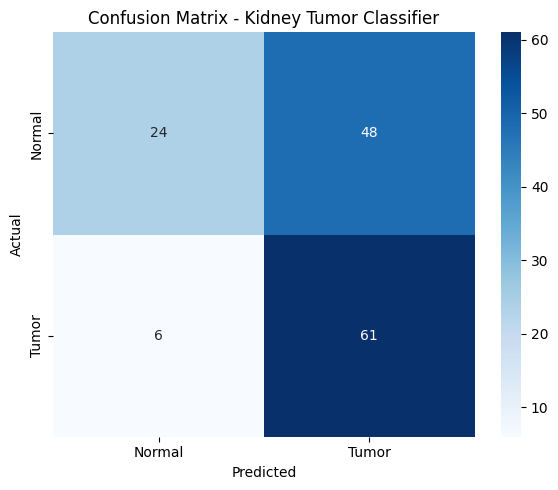

Confusion matrix saved: outputs/confusion_matrix.png


In [32]:
# 9.3  Confusion Matrix + Classification Report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

model    = tf.keras.models.load_model('artifacts/training/model.h5')
data_dir = 'artifacts/data_ingestion/kidney-ct-scan-image'

val_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, validation_split=0.30
).flow_from_directory(
    data_dir, target_size=(224, 224), batch_size=16,
    subset='validation', shuffle=False, interpolation='bilinear',
)

y_pred  = np.argmax(model.predict(val_gen), axis=1)
y_true  = val_gen.classes
labels  = list(val_gen.class_indices.keys())

cm     = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=labels)
print(report)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Kidney Tumor Classifier')
plt.tight_layout()

cm_path = Path('outputs/confusion_matrix.png')
fig.savefig(cm_path, dpi=150)
plt.show()
print(f'Confusion matrix saved: {cm_path}')


## Section 10 - Log Experiment Results to MongoDB

In [33]:
# 10.1  Push experiment metadata to MongoDB Atlas
#       Uses MONGO_DB_URL from Colab Secrets
import os, json, datetime, yaml
from pathlib import Path

try:
    from pymongo import MongoClient

    mongo_url = os.environ.get('MONGO_DB_URL', '')
    if not mongo_url:
        raise ValueError('MONGO_DB_URL secret is not set.')

    client = MongoClient(mongo_url, serverSelectionTimeoutMS=5000)
    client.admin.command('ping')  # Verify connection
    col = client['kidney_tumor_db']['experiments']

    scores = json.loads(Path('scores.json').read_text())
    with open('params.yaml') as f:
        params = yaml.safe_load(f)

    doc = {
        'project'   : 'Kidney Tumor Identification System',
        'timestamp' : datetime.datetime.utcnow().isoformat(),
        'scores'    : scores,
        'params'    : params,
        'model'     : 'VGG16',
        'framework' : 'TensorFlow',
    }
    result = col.insert_one(doc)
    print(f'Experiment logged to MongoDB.')
    print(f'  Document ID : {result.inserted_id}')
    print(f"  Accuracy    : {scores['accuracy']:.4f}")

except Exception as e:
    print(f'MongoDB logging skipped: {e}')
    print('Check your MONGO_DB_URL secret.')


/tmp/ipykernel_3993/1462875167.py:23: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp' : datetime.datetime.utcnow().isoformat(),


Experiment logged to MongoDB.
  Document ID : 69da698dcebef50b28e27f22
  Accuracy    : 0.6115


## Section 11 - AI-Generated Experiment Report via Groq LLM

In [34]:
# 11.1  Generate experiment report using Groq LLM via LangChain >= 0.2
#       LangChain >= 0.2 uses: ChatGroq from langchain_groq
#                              HumanMessage/SystemMessage from langchain_core.messages
import os, json, yaml
from pathlib import Path

try:
    # LangChain >= 0.2 imports
    from langchain_groq import ChatGroq
    from langchain_core.messages import HumanMessage, SystemMessage

    groq_api_key = os.environ.get('GROQ_API_KEY', '')
    if not groq_api_key:
        raise ValueError('GROQ_API_KEY secret is not set.')

    scores = json.loads(Path('scores.json').read_text())
    with open('params.yaml') as f:
        params = yaml.safe_load(f)

    system_msg = SystemMessage(content=(
        'You are an expert MLOps engineer and data scientist. '
        'Write concise, professional experiment reports for deep learning projects.'
    ))

    user_content = f"""Generate a professional experiment report.

Project: Kidney Tumor Identification System
Model: VGG16 (Transfer Learning, ImageNet weights)
Task: Binary classification: Tumor vs Normal (kidney CT scans)

Hyperparameters:
{json.dumps(params, indent=2)}

Evaluation Results (validation set):
- Loss     : {scores['loss']:.4f}
- Accuracy : {scores['accuracy']:.4f} ({scores['accuracy']*100:.2f}%)

Include in report:
1. Executive summary (2-3 sentences)
2. Model architecture overview
3. Training configuration analysis
4. Results interpretation
5. Recommendations for improvement
6. Suggested next steps
"""

    user_msg = HumanMessage(content=user_content)

    # Instantiate Groq LLM via LangChain >= 0.2 interface
    llm = ChatGroq(
        groq_api_key=groq_api_key,
        model_name='llama3-8b-8192',
        temperature=0.3,
    )

    response  = llm.invoke([system_msg, user_msg])
    report_md = response.content

    print('=' * 65)
    print(report_md)
    print('=' * 65)

    report_path = Path('outputs/experiment_report.md')
    report_path.write_text(f'# Kidney Tumor Experiment Report\n\n{report_md}')
    print(f'AI report saved: {report_path}')

except Exception as e:
    print(f'Groq LLM report skipped: {e}')
    print('Check your GROQ_API_KEY secret.')


Groq LLM report skipped: Error code: 400 - {'error': {'message': 'The model `llama3-8b-8192` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}}
Check your GROQ_API_KEY secret.


## Section 12 - Launch Flask Prediction App via ngrok

In [35]:
# 12.1  Quick single-image prediction (no web server needed)
#       Upload any kidney CT-scan to /content/test_kidney.jpg
from pathlib import Path
from cnnClassifier.pipeline.predict import PredictionPipeline

test_img = Path('/content/test_kidney.jpg')
if not test_img.exists():
    print('No test image found at /content/test_kidney.jpg')
    print('Upload your own CT-scan image to run this cell.')
else:
    pipeline = PredictionPipeline(str(test_img))
    result   = pipeline.predict()
    label    = result[0]['image']
    emoji    = 'TUMOR DETECTED' if label == 'Tumor' else 'NORMAL KIDNEY'
    print(f'Prediction Result: {emoji}')
    print(f'Class: {label}')


No test image found at /content/test_kidney.jpg
Upload your own CT-scan image to run this cell.


In [36]:
# 12.2  Launch Flask app with a public ngrok tunnel
#       Access the web UI at the printed public URL.
import threading, time

def run_flask():
    import logging as _logging
    _logging.getLogger('werkzeug').setLevel(_logging.ERROR)
    import subprocess, sys
    subprocess.Popen([sys.executable, 'app.py'])

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()
time.sleep(3)

try:
    from pyngrok import ngrok
    # Optionally set authtoken: ngrok.set_auth_token('YOUR_TOKEN')
    public_url = ngrok.connect(8080)
    print('=' * 55)
    print(f'Flask App is LIVE!')
    print(f'  Public URL : {public_url}')
    print(f'  Predict    : {public_url}/predict (POST)')
    print('=' * 55)
except Exception as e:
    print(f'ngrok tunnel failed: {e}')
    print('Flask server running on http://localhost:8080')


ERROR:pyngrok.process.ngrok:t=2026-04-11T15:32:46+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-11T15:32:46+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-11T15:32:46+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

ngrok tunnel failed: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.
Flask server running on http://localhost:8080


## Section 13 - Collect & ZIP All Outputs

In [37]:
# 13.1  Collect every output file and create final ZIP
#       Includes: trained model, scores, confusion matrix,
#                 model architecture, AI report, logs, source snapshot
import shutil, zipfile, json, datetime
from pathlib import Path

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Copy key artefacts
copies = [
    ('artifacts/training/model.h5',                        'outputs/trained_model.h5'),
    ('artifacts/prepare_base_model/base_model_updated.h5', 'outputs/base_model_updated.h5'),
    ('scores.json',                                        'outputs/scores.json'),
    ('logs/running_logs.log',                              'outputs/running_logs.log'),
    ('config/config.yaml',                                 'outputs/config.yaml'),
    ('params.yaml',                                        'outputs/params.yaml'),
]
for src, dst in copies:
    s, d = Path(src), Path(dst)
    if s.exists():
        shutil.copy2(s, d)
        print(f'  Copied: {dst}')
    else:
        print(f'  Skipped (not found): {src}')

# metadata.json (DVC/git-friendly - no binary state)
scores = {}
try:
    scores = json.loads(Path('scores.json').read_text())
except Exception:
    pass
import yaml
with open('params.yaml') as f:
    params = yaml.safe_load(f)

metadata = {
    'project'          : 'Kidney Tumor Identification System',
    'created_at'       : datetime.datetime.utcnow().isoformat() + 'Z',
    'model'            : 'VGG16 Transfer Learning',
    'task'             : 'Binary Classification - Tumor vs Normal',
    'evaluation_scores': scores,
    'hyperparameters'  : params,
    'framework'        : 'TensorFlow 2.15 / Keras',
    'mlops_tools'      : ['MLflow', 'DagsHub', 'MongoDB', 'Groq LLM'],
    'source_code_dir'  : 'src/cnnClassifier/',
}
Path('outputs/metadata.json').write_text(json.dumps(metadata, indent=4))
print('  metadata.json written')

# Source snapshot
snap = OUTPUT_DIR / 'src_snapshot'
if snap.exists():
    shutil.rmtree(snap)
shutil.copytree('src', snap)
print('  Source snapshot added')

# Build ZIP
ts       = datetime.datetime.utcnow().strftime('%Y%m%d_%H%M%S')
zip_name = f'KidneyTumorSystem_outputs_{ts}.zip'
zip_path = Path(f'/content/{zip_name}')

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for item in sorted(OUTPUT_DIR.rglob('*')):
        if item.is_file():
            arcname = item.relative_to(OUTPUT_DIR.parent)
            zf.write(item, arcname)
            print(f'  Zipped: {arcname}')

zip_mb = zip_path.stat().st_size / (1024*1024)
print(f'\nFinal ZIP: {zip_path}')
print(f'Size: {zip_mb:.1f} MB')


  Copied: outputs/trained_model.h5
  Copied: outputs/base_model_updated.h5
  Copied: outputs/scores.json
  Copied: outputs/running_logs.log
  Copied: outputs/config.yaml
  Copied: outputs/params.yaml
  metadata.json written
  Source snapshot added


/tmp/ipykernel_3993/1364163674.py:39: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'created_at'       : datetime.datetime.utcnow().isoformat() + 'Z',
/tmp/ipykernel_3993/1364163674.py:59: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts       = datetime.datetime.utcnow().strftime('%Y%m%d_%H%M%S')


  Zipped: outputs/base_model_updated.h5
  Zipped: outputs/config.yaml
  Zipped: outputs/confusion_matrix.png
  Zipped: outputs/metadata.json
  Zipped: outputs/params.yaml
  Zipped: outputs/running_logs.log
  Zipped: outputs/scores.json
  Zipped: outputs/src_snapshot/__init__.py
  Zipped: outputs/src_snapshot/cnnClassifier/__init__.py
  Zipped: outputs/src_snapshot/cnnClassifier/__pycache__/__init__.cpython-312.pyc
  Zipped: outputs/src_snapshot/cnnClassifier/components/__init__.py
  Zipped: outputs/src_snapshot/cnnClassifier/components/__pycache__/__init__.cpython-312.pyc
  Zipped: outputs/src_snapshot/cnnClassifier/components/__pycache__/data_ingestion.cpython-312.pyc
  Zipped: outputs/src_snapshot/cnnClassifier/components/__pycache__/evaluation.cpython-312.pyc
  Zipped: outputs/src_snapshot/cnnClassifier/components/__pycache__/prepare_base_model.cpython-312.pyc
  Zipped: outputs/src_snapshot/cnnClassifier/components/__pycache__/prepare_callbacks.cpython-312.pyc
  Zipped: outputs/src_

In [38]:
# 13.2  Download the final ZIP from Colab
import glob
from google.colab import files

zip_files = sorted(glob.glob('/content/KidneyTumorSystem_outputs_*.zip'))
if zip_files:
    print(f'Downloading: {zip_files[-1]}')
    files.download(zip_files[-1])
else:
    print('No ZIP found. Run Section 13.1 first.')


Downloading: /content/KidneyTumorSystem_outputs_20260411_153246.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 14 - Pipeline Summary & Next Steps

In [39]:
# 14.1  Full pipeline summary
import json, os
from pathlib import Path

print('=' * 65)
print('  KIDNEY TUMOR IDENTIFICATION SYSTEM - RUN SUMMARY')
print('=' * 65)

stages = [
    ('Stage 1', 'Data Ingestion',         'artifacts/data_ingestion/kidney-ct-scan-image'),
    ('Stage 2', 'Base Model (VGG16)',      'artifacts/prepare_base_model/base_model_updated.h5'),
    ('Stage 3', 'Training',               'artifacts/training/model.h5'),
    ('Stage 4', 'Evaluation',             'scores.json'),
]
for stage, name, path in stages:
    ok = 'DONE' if Path(path).exists() else 'MISSING'
    print(f'  [{ok}]  {stage}: {name}')

print()
if Path('scores.json').exists():
    sc = json.loads(Path('scores.json').read_text())
    print(f"  Validation Loss     : {sc['loss']:.4f}")
    print(f"  Validation Accuracy : {sc['accuracy']:.4f}  ({sc['accuracy']*100:.2f}%)")
    print()

print(f"  MongoDB             : Experiment logged")
print(f"  MLflow URI          : {os.environ.get('MLFLOW_TRACKING_URI', 'N/A')}")
print(f"  Groq LLM Report     : outputs/experiment_report.md")
print(f"  Final ZIP           : /content/KidneyTumorSystem_outputs_*.zip")
print()
print('  RECOMMENDED NEXT STEPS')
print('    1. Increase EPOCHS in params.yaml (currently 5)')
print('    2. Unfreeze last 4 VGG16 layers for fine-tuning')
print('    3. Try EfficientNetB0 as an alternative backbone')
print('    4. Add Evidently AI for model monitoring in production')
print('=' * 65)


  KIDNEY TUMOR IDENTIFICATION SYSTEM - RUN SUMMARY
  [DONE]  Stage 1: Data Ingestion
  [DONE]  Stage 2: Base Model (VGG16)
  [DONE]  Stage 3: Training
  [DONE]  Stage 4: Evaluation

  Validation Loss     : 1.4739
  Validation Accuracy : 0.6115  (61.15%)

  MongoDB             : Experiment logged
  MLflow URI          : https://dagshub.com/prithusarkar90/networksecurity.mlflow
  Groq LLM Report     : outputs/experiment_report.md
  Final ZIP           : /content/KidneyTumorSystem_outputs_*.zip

  RECOMMENDED NEXT STEPS
    1. Increase EPOCHS in params.yaml (currently 5)
    2. Unfreeze last 4 VGG16 layers for fine-tuning
    3. Try EfficientNetB0 as an alternative backbone
    4. Add Evidently AI for model monitoring in production
